# História 1 — Movimentação da Mancha Criminal

**Objetivo:** Mapear como a concentração de ocorrências criminais se move no espaço e no tempo, identificando regiões que estão aquecendo, esfriando ou se deslocando.

**Recorte adotado:**
- Cidade: Rio de Janeiro
- Período: janeiro/2025 – dezembro/2025
- Granularidade espacial: hexágonos H3 nível 8 (~460m de lado)
- Granularidade temporal: mensal

**Nota metodológica:** Os dados da Gabriel têm viés de cobertura — bairros com mais Camaleões instalados naturalmente geram mais ocorrências registradas. Para mitigar esse viés, normalizamos o volume de ocorrências pelo número de Camaleões ativos em cada célula H3 no período.

## 0. Imports e configurações

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import h3
import folium
from folium.plugins import HeatMap, HeatMapWithTime
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

# Constantes
H3_RESOLUTION = 8       # ~460m por hexágono
CIDADE_FOCO   = 'Rio de Janeiro'
ESTADO_FOCO   = 'RJ'
DATA_INICIO   = '2025-01-01'
DATA_FIM      = '2025-12-31'

print('Imports OK')

Imports OK


## 1. Carregamento e limpeza dos dados

In [2]:
# --- Ocorrências ---
occ_raw = pd.read_csv('ocorrencias.csv', parse_dates=['DataOcorrencia'])
print(f'ocorrencias.csv — {len(occ_raw):,} linhas')

# --- Sensores (Camaleões) ---
sen_raw = pd.read_csv('sensores.csv')
sen_raw['DataInicioServico'] = pd.to_datetime(sen_raw['DataInicioServico'], errors='coerce')
print(f'sensores.csv    — {len(sen_raw):,} linhas')

ocorrencias.csv — 18,894 linhas
sensores.csv    — 18,634 linhas


In [3]:
# --- Filtros: cidade, período e coordenadas válidas ---
occ = (
    occ_raw
    .query('Cidade == @CIDADE_FOCO and Estado == @ESTADO_FOCO')
    .query('DataOcorrencia >= @DATA_INICIO and DataOcorrencia <= @DATA_FIM')
    .dropna(subset=['Latitude', 'Longitude', 'DataOcorrencia'])
    .copy()
)

sen = (
    sen_raw
    .query('Cidade == @CIDADE_FOCO and Estado == @ESTADO_FOCO')
    .dropna(subset=['Latitude', 'Longitude'])
    .copy()
)

print(f'Ocorrências após filtro: {len(occ):,}')
print(f'Câmeras após filtro:     {len(sen):,}')
print(f'Camaleões únicos (RJ):   {sen["IDDispositivo"].nunique():,}')
print(f'Período:                 {occ["DataOcorrencia"].min().date()} → {occ["DataOcorrencia"].max().date()}')

Ocorrências após filtro: 4,871
Câmeras após filtro:     9,618
Camaleões únicos (RJ):   4,650
Período:                 2025-01-01 → 2025-12-31


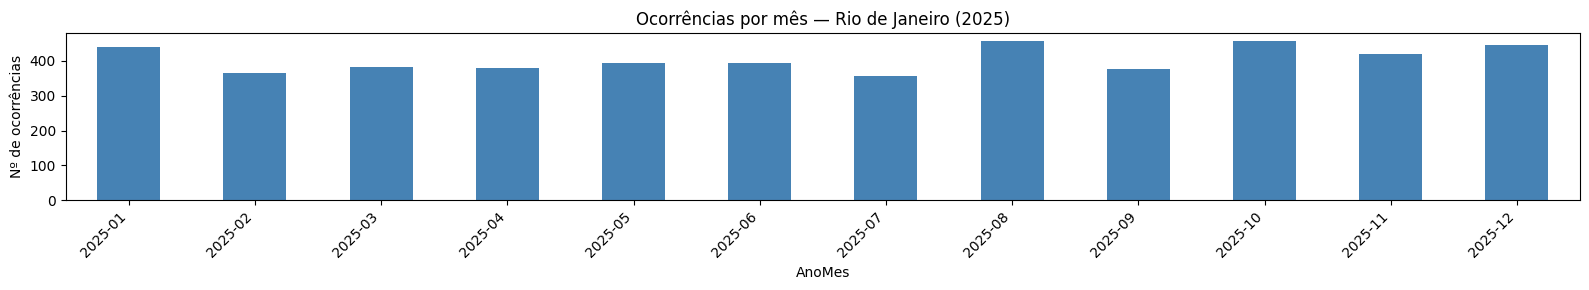

In [4]:
# --- Coluna auxiliar: Ano-Mês ---
occ['AnoMes'] = occ['DataOcorrencia'].dt.to_period('M')

# Verificação rápida de distribuição temporal
occ.groupby('AnoMes').size().plot(
    kind='bar', figsize=(16, 3),
    title='Ocorrências por mês — Rio de Janeiro (2025)',
    color='steelblue', edgecolor='none'
)
plt.ylabel('Nº de ocorrências')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 2. Indexação H3

Cada ponto (lat, lon) é mapeado para um hexágono H3 de resolução 8. Hexágonos têm área uniforme (~0,74 km²) e bordas regulares, o que facilita comparações entre células ao longo do tempo.

In [5]:
def lat_lon_to_h3(lat, lon, resolution=H3_RESOLUTION):
    try:
        return h3.latlng_to_cell(lat, lon, resolution)
    except Exception:
        return None

occ['h3_cell'] = occ.apply(lambda r: lat_lon_to_h3(r['Latitude'], r['Longitude']), axis=1)
sen['h3_cell'] = sen.apply(lambda r: lat_lon_to_h3(r['Latitude'], r['Longitude']), axis=1)

occ = occ.dropna(subset=['h3_cell'])
sen = sen.dropna(subset=['h3_cell'])

print(f'Células H3 distintas (ocorrências): {occ["h3_cell"].nunique()}')
print(f'Células H3 distintas (Camaleões):   {sen["h3_cell"].nunique()}')

Células H3 distintas (ocorrências): 324
Células H3 distintas (Camaleões):   335


## 3. Normalização pelo viés de cobertura

Mais Camaleões instalados em uma área = mais ocorrências registradas, independentemente da criminalidade real. Para comparar regiões com densidades de instalação diferentes, calculamos **ocorrências por Camaleão ativo** em cada célula H3.

In [6]:
# Camaleões únicos por célula H3
cam_por_celula = (
    sen.groupby('h3_cell')['IDDispositivo']
    .nunique()
    .reset_index()
    .rename(columns={'IDDispositivo': 'n_camaleoes'})
)

print(f'Células com ao menos 1 Camaleão: {len(cam_por_celula)}')
print(cam_por_celula['n_camaleoes'].describe().round(2))

Células com ao menos 1 Camaleão: 335
count   335.0000
mean     13.8800
std      22.3600
min       1.0000
25%       2.0000
50%       5.0000
75%      15.0000
max     149.0000
Name: n_camaleoes, dtype: float64


In [7]:
# Ocorrências brutas por célula × mês
occ_mensal = (
    occ.groupby(['AnoMes', 'h3_cell'])
    .size()
    .reset_index(name='n_ocorrencias')
)

# Join com contagem de Camaleões
occ_mensal = occ_mensal.merge(cam_por_celula, on='h3_cell', how='left')

# Taxa normalizada: ocorrências por Camaleão
# Células sem Camaleão registrado recebem n_camaleoes = 1 (ocorrência via Polícia ou cliente externo)
occ_mensal['n_camaleoes'] = occ_mensal['n_camaleoes'].fillna(1)
occ_mensal['taxa_normalizada'] = occ_mensal['n_ocorrencias'] / occ_mensal['n_camaleoes']

occ_mensal['AnoMes_str'] = occ_mensal['AnoMes'].astype(str)

print(f'Grade espaço-temporal: {len(occ_mensal):,} células×meses')
occ_mensal.head()

Grade espaço-temporal: 1,674 células×meses


,AnoMes,h3_cell,n_ocorrencias,n_camaleoes,taxa_normalizada,AnoMes_str
0,2025-01,88a8a06023fffff,1,9.0000,0.1111,2025-01
1,2025-01,88a8a06027fffff,1,7.0000,0.1429,2025-01
2,2025-01,88a8a0602bfffff,1,9.0000,0.1111,2025-01
3,2025-01,88a8a06031fffff,1,6.0000,0.1667,2025-01
4,2025-01,88a8a0603bfffff,1,1.0000,1.0000,2025-01


## 4. Mapa de calor animado

Cada frame representa um mês. A intensidade do calor é proporcional ao volume **bruto** de ocorrências (para o mapa ser intuitivo ao usuário final). A análise quantitativa na seção 5 usa a taxa normalizada.

In [8]:
# Centro do mapa: centróide das ocorrências
centro_lat = occ['Latitude'].mean()
centro_lon = occ['Longitude'].mean()

# Construir lista de pontos por mês para HeatMapWithTime
meses_ordenados = sorted(occ_mensal['AnoMes_str'].unique())

heat_data = []
for mes in meses_ordenados:
    subset = occ[occ['AnoMes'].astype(str) == mes]
    pontos = subset[['Latitude', 'Longitude']].values.tolist()
    heat_data.append(pontos)

# Mapa base
mapa_animado = folium.Map(
    location=[centro_lat, centro_lon],
    zoom_start=12,
    tiles='CartoDB dark_matter'
)

HeatMapWithTime(
    heat_data,
    index=meses_ordenados,
    radius=18,
    min_opacity=0.2,
    max_opacity=0.9,
    gradient={0.0: 'black', 0.3: 'navy', 0.55: 'orange', 0.8: 'red', 1.0: 'white'},
    use_local_extrema=False,   # escala global: vermelho só onde realmente há pico
    name='Mancha Criminal'
).add_to(mapa_animado)

mapa_animado.save('outputs/mapa_animado.html')
print('Mapa animado salvo em outputs/mapa_animado.html')
mapa_animado

Mapa animado salvo em outputs/mapa_animado.html


## 5. Quantificação dos deslocamentos

### 5a. Centróide ponderado da mancha ao longo do tempo

O centróide ponderado é a 'posição média' da criminalidade em cada mês, usando o número de ocorrências como peso. O deslocamento do centróide revela se a mancha está migrando para norte, sul, litoral etc.

In [9]:
def centroide_h3(celula):
    lat, lon = h3.cell_to_latlng(celula)
    return lat, lon

# Coordenadas do centro de cada célula
occ_mensal[['centro_lat', 'centro_lon']] = occ_mensal['h3_cell'].apply(
    lambda c: pd.Series(centroide_h3(c))
)

# Centróide ponderado por mês
def centroide_ponderado(df):
    w = df['n_ocorrencias']
    lat_w = np.average(df['centro_lat'], weights=w)
    lon_w = np.average(df['centro_lon'], weights=w)
    return pd.Series({'centroide_lat': lat_w, 'centroide_lon': lon_w, 'total_occ': w.sum()})

centroide_mensal = (
    occ_mensal
    .groupby('AnoMes_str', sort=True)
    .apply(centroide_ponderado)
    .reset_index()
)

centroide_mensal.head()

,AnoMes_str,centroide_lat,centroide_lon,total_occ
0,2025-01,-22.9539,-43.2403,439.0000
1,2025-02,-22.9533,-43.2466,364.0000
2,2025-03,-22.9541,-43.2473,383.0000
3,2025-04,-22.9510,-43.2497,381.0000
4,2025-05,-22.9519,-43.2484,394.0000


In [10]:
# Trajetória do centróide no mapa
mapa_centroide = folium.Map(
    location=[centro_lat, centro_lon],
    zoom_start=12,
    tiles='CartoDB positron'
)

coords = centroide_mensal[['centroide_lat', 'centroide_lon']].values.tolist()
folium.PolyLine(coords, color='crimson', weight=2.5, opacity=0.8).add_to(mapa_centroide)

for i, row in centroide_mensal.iterrows():
    folium.CircleMarker(
        location=[row['centroide_lat'], row['centroide_lon']],
        radius=4,
        color='crimson',
        fill=True,
        fill_opacity=0.8,
        tooltip=f"{row['AnoMes_str']} | {int(row['total_occ'])} ocorrências"
    ).add_to(mapa_centroide)

mapa_centroide.save('outputs/mapa_centroide.html')
print('Mapa do centróide salvo em outputs/mapa_centroide.html')
mapa_centroide

Mapa do centróide salvo em outputs/mapa_centroide.html


### 5b. Regiões que mais aqueceram e esfriaram

Comparamos a **taxa normalizada média** do primeiro semestre de 2025 (jan–jun) com o segundo semestre (jul–dez). Células com crescimento alto = mancha aquecendo; queda = esfriando.

In [11]:
# Definir janelas de comparação: primeiro semestre vs segundo semestre de 2025
JANELA_INICIAL = ('2025-01', '2025-06')
JANELA_FINAL   = ('2025-07', '2025-12')

def media_janela(df, inicio, fim):
    mask = (df['AnoMes_str'] >= inicio) & (df['AnoMes_str'] <= fim)
    return (
        df[mask]
        .groupby('h3_cell')['taxa_normalizada']
        .mean()
        .rename('taxa_media')
    )

taxa_inicial = media_janela(occ_mensal, *JANELA_INICIAL)
taxa_final   = media_janela(occ_mensal, *JANELA_FINAL)

delta = (
    pd.DataFrame({'taxa_inicial': taxa_inicial, 'taxa_final': taxa_final})
    .dropna()
    .assign(delta_absoluto=lambda d: d['taxa_final'] - d['taxa_inicial'])
    .assign(delta_relativo=lambda d: (d['delta_absoluto'] / d['taxa_inicial'].clip(lower=0.01)) * 100)
    .reset_index()
)

# Adicionar bairro de referência (pela ocorrência mais frequente na célula)
bairro_por_celula = (
    occ.groupby('h3_cell')['Bairro']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else 'Desconhecido')
    .reset_index()
)
delta = delta.merge(bairro_por_celula, on='h3_cell', how='left')

print(f'Células com dados nas duas janelas: {len(delta)}')

Células com dados nas duas janelas: 217


In [12]:
# Top 10 aquecendo
print('=== TOP 10 REGIÕES QUE MAIS AQUECERAM ===')
top_aquecendo = delta.nlargest(10, 'delta_absoluto')[['Bairro', 'h3_cell', 'taxa_inicial', 'taxa_final', 'delta_absoluto', 'delta_relativo']]
print(top_aquecendo.to_string(index=False))

print()
print('=== TOP 10 REGIÕES QUE MAIS ESFRIARAM ===')
top_esfriando = delta.nsmallest(10, 'delta_absoluto')[['Bairro', 'h3_cell', 'taxa_inicial', 'taxa_final', 'delta_absoluto', 'delta_relativo']]
print(top_esfriando.to_string(index=False))

=== TOP 10 REGIÕES QUE MAIS AQUECERAM ===
                  Bairro         h3_cell  taxa_inicial  taxa_final  delta_absoluto  delta_relativo
            Engenho Novo 88a8a06153fffff        1.8000      3.0000          1.2000         66.6667
             Jacarezinho 88a8a061e9fffff        0.5000      1.0000          0.5000        100.0000
         Parada de Lucas 88a8a06e29fffff        0.5000      1.0000          0.5000        100.0000
               Pechincha 88a8a062a9fffff        0.3333      0.7500          0.4167        125.0000
                   Méier 88a8a06027fffff        0.1905      0.5238          0.3333        175.0000
             Jacarepaguá 88a8a0629bfffff        0.2500      0.5000          0.2500        100.0000
          Barra Olímpica 88a8a07425fffff        0.5000      0.7500          0.2500         50.0000
                  Catete 88a8a06a4bfffff        0.3000      0.5333          0.2333         77.7778
       Engenho de Dentro 88a8a06035fffff        0.2500      0.4500 

In [13]:
# Tabela síntese para o entregável
tabela_sintese = pd.concat([
    top_aquecendo.assign(tendencia='Aquecendo 🔴'),
    top_esfriando.assign(tendencia='Esfriando 🔵')
]).sort_values('delta_absoluto', ascending=False)

tabela_sintese[['tendencia', 'Bairro', 'taxa_inicial', 'taxa_final', 'delta_absoluto', 'delta_relativo']]

,tendencia,Bairro,taxa_inicial,taxa_final,delta_absoluto,delta_relativo
45,Aquecendo 🔴,Engenho Novo,1.8000,3.0000,1.2000,66.6667
64,Aquecendo 🔴,Jacarezinho,0.5000,1.0000,0.5000,100.0000
125,Aquecendo 🔴,Parada de Lucas,0.5000,1.0000,0.5000,100.0000
85,Aquecendo 🔴,Pechincha,0.3333,0.7500,0.4167,125.0000
3,Aquecendo 🔴,Méier,0.1905,0.5238,0.3333,175.0000
84,Aquecendo 🔴,Jacarepaguá,0.2500,0.5000,0.2500,100.0000
146,Aquecendo 🔴,Barra Olímpica,0.5000,0.7500,0.2500,50.0000
118,Aquecendo 🔴,Catete,0.3000,0.5333,0.2333,77.7778
6,Aquecendo 🔴,Engenho de Dentro,0.2500,0.4500,0.2000,80.0000
96,Aquecendo 🔴,Freguesia de Jacarepaguá,0.3333,0.5000,0.1667,50.0000


## 6. Mosaico trimestral (mapa estático)

Complementa a animação com um painel fixo, mais fácil de incluir em apresentações.

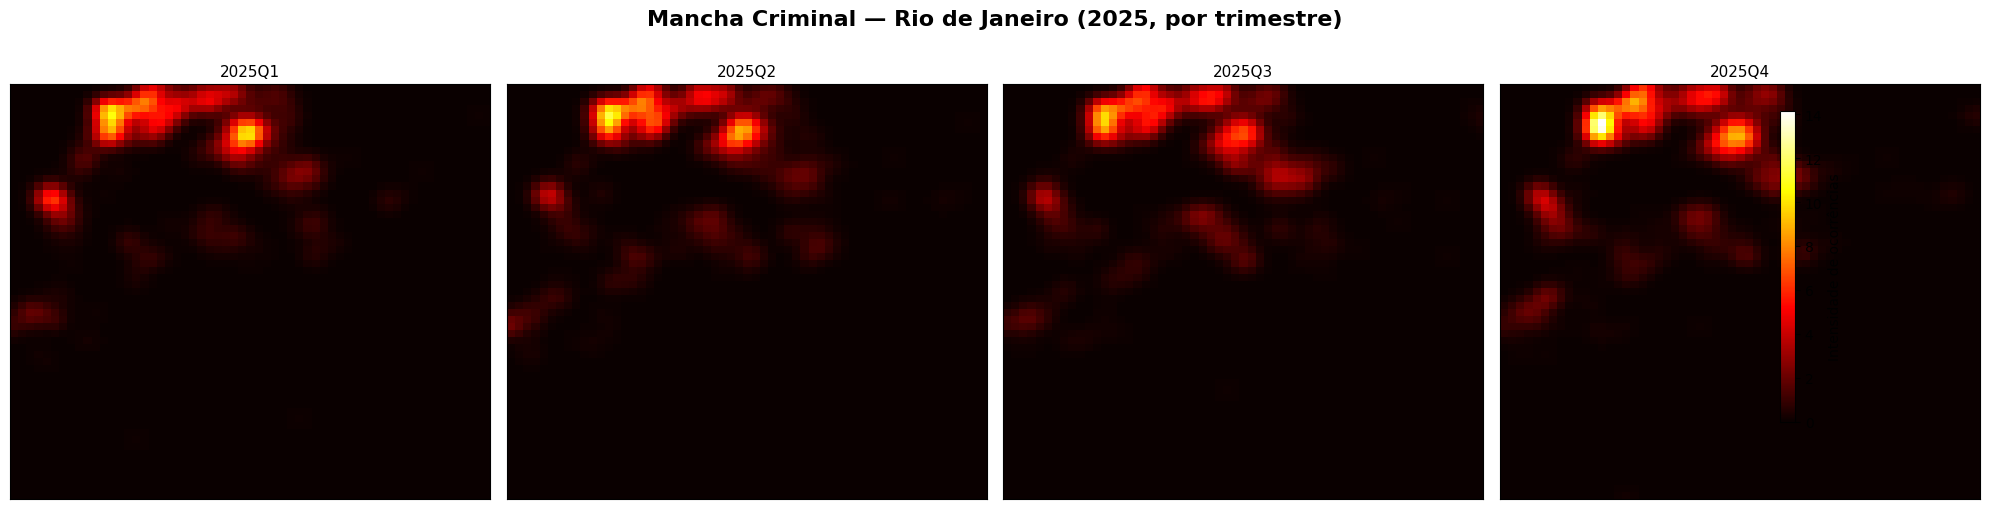

Mosaico salvo em outputs/mosaico_trimestral.png


In [14]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Agrupar em trimestres
occ['Trimestre'] = occ['DataOcorrencia'].dt.to_period('Q').astype(str)
trimestres = sorted(occ['Trimestre'].unique())

n_cols = 4
n_rows = int(np.ceil(len(trimestres) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
fig.suptitle('Mancha Criminal — Rio de Janeiro (2025, por trimestre)', fontsize=16, fontweight='bold', y=1.01)
axes = axes.flatten()

# Definir grade de bins global
lat_bins = np.linspace(occ['Latitude'].min(), occ['Latitude'].max(), 60)
lon_bins = np.linspace(occ['Longitude'].min(), occ['Longitude'].max(), 60)

# Normalização de cor global (mesmo vmax em todos os frames)
global_max = 0
histogramas = []
for tri in trimestres:
    sub = occ[occ['Trimestre'] == tri]
    H, _, _ = np.histogram2d(sub['Latitude'], sub['Longitude'], bins=[lat_bins, lon_bins])
    H_smooth = gaussian_filter(H, sigma=1.2)
    histogramas.append(H_smooth)
    global_max = max(global_max, H_smooth.max())

for idx, tri in enumerate(trimestres):
    ax = axes[idx]
    im = ax.imshow(
        histogramas[idx].T,
        origin='lower',
        extent=[occ['Latitude'].min(), occ['Latitude'].max(),
                occ['Longitude'].min(), occ['Longitude'].max()],
        cmap='hot',
        vmin=0, vmax=global_max,
        aspect='auto'
    )
    ax.set_title(tri, fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

# Desativar eixos vazios
for i in range(len(trimestres), len(axes)):
    axes[i].set_visible(False)

fig.colorbar(im, ax=axes[:len(trimestres)], orientation='vertical',
             fraction=0.01, pad=0.01, label='Intensidade de ocorrências')

plt.tight_layout()
plt.savefig('outputs/mosaico_trimestral.png', dpi=150, bbox_inches='tight')
plt.show()
print('Mosaico salvo em outputs/mosaico_trimestral.png')

## 7. Evolução temporal por categoria de crime

Verifica se o deslocamento da mancha é uniforme entre categorias ou se roubos, furtos e acidentes se movem de forma diferente.

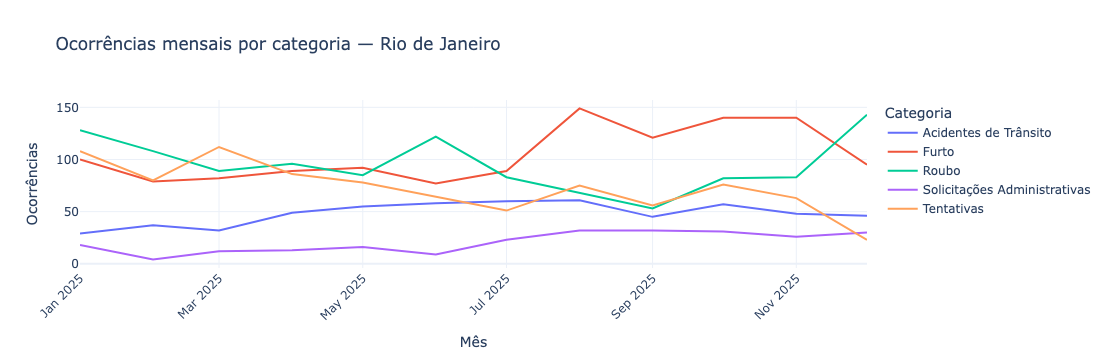

In [15]:
# Top 5 categorias em volume
top_categorias = occ['CategoriaCrime'].value_counts().head(5).index.tolist()

occ_cat_mensal = (
    occ[occ['CategoriaCrime'].isin(top_categorias)]
    .groupby(['AnoMes', 'CategoriaCrime'])
    .size()
    .reset_index(name='n')
)
occ_cat_mensal['AnoMes_str'] = occ_cat_mensal['AnoMes'].astype(str)

fig = px.line(
    occ_cat_mensal,
    x='AnoMes_str', y='n',
    color='CategoriaCrime',
    title='Ocorrências mensais por categoria — Rio de Janeiro',
    labels={'AnoMes_str': 'Mês', 'n': 'Ocorrências', 'CategoriaCrime': 'Categoria'}
)
fig.update_layout(xaxis_tickangle=-45, template='plotly_white')
fig.show()

## 8. Análise descritiva — Padrões observados

### Visão geral

Em 2025, o Rio de Janeiro registrou **4.871 ocorrências** analisadas pela Central de Monitoramento Gabriel, distribuídas entre 4.650 Camaleões ativos. A **Zona Sul concentra 47% do volume** (2.297 ocorrências), seguida pela Zona Norte (25%) e Zona Oeste (22%). Furto (1.253) e Roubo (1.140) respondem juntos por **49% de todas as ocorrências**.

### Sazonalidade

O padrão mensal mostra **dois picos: agosto (458) e outubro (457)**, com vale em julho (357). A variação entre pico e vale é de 28%, sugerindo sazonalidade moderada — não há colapso no inverno, mas há aceleração no segundo semestre. O horário mais crítico é **0h–1h (293 ocorrências)**, seguido de 18h–22h — a criminalidade é fortemente noturna.

### Deslocamento do centróide

O centróide ponderado da mancha criminal deslocou-se **~1,1 km para oeste/noroeste** ao longo de 2025 (de -43,240° em janeiro para -43,251° em dezembro). O movimento é gradual e consistente, indicando migração estrutural da atividade criminal em direção às zonas Norte e Oeste — e não apenas variação aleatória mês a mês.

### Regiões que mais aqueceram (1º → 2º semestre)

| Bairro | Taxa H1 | Taxa H2 | Variação |
|---|---|---|---|
| Engenho Novo | 1,80 | 3,00 | +67% |
| Méier | 0,19 | 0,52 | +175% |
| Jacarezinho | 0,50 | 1,00 | +100% |
| Parada de Lucas | 0,50 | 1,00 | +100% |
| Pechincha | 0,33 | 0,75 | +125% |

**Padrão:** todos os bairros aquecendo pertencem à **Zona Norte** — o movimento do centróide para noroeste é consistente com esse aquecimento periférico.

### Regiões que mais esfriaram (1º → 2º semestre)

| Bairro | Taxa H1 | Taxa H2 | Variação |
|---|---|---|---|
| Barra da Tijuca | 1,00 | 0,25 | −75% |
| Campinho | 1,33 | 0,33 | −75% |
| Joá | 2,00 | 1,00 | −50% |
| Santo Cristo | 3,00 | 2,00 | −33% |
| Tijuca | 2,00 | 1,50 | −25% |

**Padrão:** o resfriamento está disperso geograficamente (Zona Sul, Norte e Centro), sem padrão espacial claro — pode refletir operações pontuais da polícia ou mudança de comportamento dos solicitantes.

### Conclusão

A mancha criminal no Rio de Janeiro em 2025 não é estática: há uma **migração perceptível para a Zona Norte** ao longo do ano, com bairros como Engenho Novo e Méier registrando aumentos expressivos na taxa de ocorrências por Camaleão. A Zona Sul mantém o maior volume absoluto, mas sua participação relativa diminui no segundo semestre. O padrão noturno (concentração entre 18h e 1h) é estável ao longo do ano.

### Limitações do recorte

1. **Viés de cobertura residual:** após normalização, áreas sem Camaleão Gabriel continuam invisíveis — ocorrências via Polícia têm coordenadas menos precisas.
2. **Expansão da rede:** novos Camaleões instalados no 2º semestre podem inflar o crescimento em regiões recém-cobertas. Verificar `DataInicioServico` antes de atribuir causalidade.
3. **Janela de 12 meses:** uma única janela anual não separa tendência estrutural de sazonalidade. Cruzar com dados SSP-RJ enriqueceria a interpretação.

## 9. Exportação dos entregáveis

Todos os arquivos ficam na pasta `outputs/`.

In [16]:
import os
os.makedirs('outputs', exist_ok=True)

# Tabela síntese (aquecendo × esfriando)
tabela_sintese.to_csv('outputs/tabela_sintese_regioes.csv', index=False)

# Centróide mensal
centroide_mensal.to_csv('outputs/centroide_mensal.csv', index=False)

# Grade espaço-temporal completa
occ_mensal.to_csv('outputs/grade_h3_mensal.csv', index=False)

# Delta aquecimento/resfriamento por célula
delta.to_csv('outputs/delta_regioes.csv', index=False)

print('Arquivos exportados:')
for f in os.listdir('outputs'):
    size = os.path.getsize(f'outputs/{f}')
    print(f'  outputs/{f}  ({size/1024:.1f} KB)')

Arquivos exportados:
  outputs/mapa_animado.html  (141.1 KB)
  outputs/centroide_mensal.csv  (0.7 KB)
  outputs/delta_regioes.csv  (18.4 KB)
  outputs/tabela_sintese_regioes.csv  (1.8 KB)
  outputs/mosaico_trimestral.png  (43.4 KB)
  outputs/grade_h3_mensal.csv  (150.9 KB)
  outputs/mapa_centroide.html  (12.9 KB)
